# 01 · Análisis exploratorio de datos (EDA)

**Fase CRISP-DM:** comprensión de los datos.

**Objetivo.** Recorrer todas las fuentes crudas, medir su estructura y calidad, explorar la variable objetivo
candidata (consultas por zona H3 res 8) y sus relaciones con la población y el territorio, y fijar los criterios
que aplicará el preprocesamiento.

| | |
|---|---|
| **Entradas** | `data/raw/*.csv` (consultas de Trufi App), `data/raw/gtfs/` (red mapeada), `data/raw/kontur_population_BO_20231101.gpkg.gz` (población) |
| **Salidas** | tablas y figuras en `resultados/01_eda/` y `metricas.json` |
| **No escribe** | nada en `data/`: todo se explora en memoria |

Todas las cifras que se citan en `EXPLICATIVO.md` salen de `resultados/01_eda/metricas.json`.

## 1. Configuración
La primera celda ubica la raíz del proyecto (la carpeta con `pyproject.toml`) para poder importar `config` y `src`.
La segunda borra los resultados anteriores de esta fase e inicia el cronómetro por sección.

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403  config, pl, pd, np, plt, colores y guardar_*
from src import eda, espacial, features, lectura, limpieza

import geopandas as gpd
import h3
from matplotlib.collections import LineCollection
from scipy.stats import spearmanr

FASE = "01_eda"
limpiar_salidas(FASE)
M = {}  # métricas de la fase → metricas.json
tiempo = cronometro()

## 2. Inventario de fuentes
**Tipo de datos:** metadatos de archivos.

Se leen las tres fuentes. Las consultas vienen en exportaciones semanales con dos esquemas de columnas (el lote de
2024 trae nombres en inglés) y algunas en Latin-1; `leer_consultas` las unifica y agrega el linaje de cada fila.

In [3]:
archivos = sorted(config.DATA_RAW.glob("*.csv"))
consultas, registro = lectura.leer_consultas(archivos)
esquemas = eda.grupos_esquema({a.name: lectura.leer_csv_seguro(a, n_rows=0)[0].columns for a in archivos})
M.update({"csv_archivos": len(archivos), "csv_esquemas": len(set(esquemas.values())),
          "csv_latin1": int((registro["codificacion"] == "latin-1").sum()), "consultas_crudas": consultas.height,
          "periodo_inicio": min(a.name[:10] for a in archivos),  # período declarado en los nombres de archivo
          "periodo_fin": max(a.name.split("_to_")[1][:10] for a in archivos),
          "ultima_consulta": str(consultas["ts"].max().date())})
guardar_tabla(registro, "archivos_consultas", FASE)
print({k: M[k] for k in ("csv_archivos", "csv_esquemas", "csv_latin1", "consultas_crudas", "periodo_inicio", "periodo_fin", "ultima_consulta")})

{'csv_archivos': 85, 'csv_esquemas': 2, 'csv_latin1': 6, 'consultas_crudas': 1927675, 'periodo_inicio': '2022-09-12', 'periodo_fin': '2024-06-09', 'ultima_consulta': '2024-06-03'}


In [4]:
gtfs = lectura.leer_gtfs(config.GTFS_DIR)
kontur = lectura.leer_kontur(config.KONTUR_GPKG_GZ)
feed = gtfs["feed_info"].iloc[0]
M.update({"gtfs_tablas": len(gtfs), "gtfs_vigencia_inicio": feed["feed_start_date"],
          "kontur_celdas_bolivia": kontur.height, "kontur_poblacion_bolivia": int(kontur["population"].sum())})
assert {h3.get_resolution(c) for c in kontur["h3_cell"].head(1000)} == {config.H3_RES}, "Kontur no está en res 8"
print(f"GTFS: {len(gtfs)} tablas, vigencia desde {feed['feed_start_date']} | "
      f"Kontur: {kontur.height:,} celdas, {M['kontur_poblacion_bolivia']:,} habitantes en Bolivia")
tiempo("inventario")

GTFS: 11 tablas, vigencia desde 20240101 | Kontur: 145,929 celdas, 12,431,735 habitantes en Bolivia
⏱ inventario: 9.7 s (acumulado 10 s)


## 3. Calidad de las consultas
**Tipo de datos:** categóricos y numéricos (nulos, duplicados, coordenadas y distancia).

Cada problema se mide sobre las filas crudas, así que los conteos pueden solaparse. Los nulos que aparecen solo en
un lote son estructurales (la columna no existía en ese esquema), no pérdida de datos.

In [5]:
nulos = guardar_tabla(eda.perfil_nulos(consultas), "nulos", FASE)
nulos.filter(pl.col("pct_global") > 0)

columna,pct_global,lote_2024,lote_original
str,f64,f64,f64
"""time_of_day""",91.608,0.0,100.0
"""year_week_number""",91.608,0.0,100.0


Se cuentan copias bajo cuatro definiciones de duplicado. Solo la copia **exacta** (todas las columnas iguales) se
eliminará: las otras pueden ser consultas legítimas repetidas.

In [6]:
datos_cols = [c for c in consultas.columns if c not in lectura.LINAJE]
od = ["lat_orig", "lon_orig", "lat_dest", "lon_dest"]
dups = eda.duplicados(consultas, {"exacto": datos_cols, "od_ts": [*od, "ts"], "usuario_ts": ["userID", "ts"],
                                  "od_ts_usuario": [*od, "ts", "userID"]})
M["duplicados_exactos"] = int(dups.filter(pl.col("definicion") == "exacto")["copias_sobrantes"].item())
guardar_tabla(dups, "duplicados", FASE)

definicion,columnas,copias_sobrantes,pct_copias
str,str,i64,f64
"""exacto""","""date, lat_orig, lon_orig, lat_…",60,0.0031
"""od_ts""","""lat_orig, lon_orig, lat_dest, …",60,0.0031
"""usuario_ts""","""userID, ts""",90,0.0047
"""od_ts_usuario""","""lat_orig, lon_orig, lat_dest, …",60,0.0031


Coordenadas imposibles: un origen en (0,0) es un GPS sin señal y uno fuera del rectángulo de Bolivia no corresponde a
esta aplicación. La columna `distancia` se contrasta con la distancia geodésica recalculada para confirmar su unidad.

In [7]:
lat, lon, bb = pl.col("lat_orig"), pl.col("lon_orig"), config.BBOX_BOLIVIA
cero = (lat == 0) | (lon == 0)
M.update({"origen_cero": consultas.filter(cero).height,
          "origen_fuera_bolivia": consultas.filter(~cero & ~limpieza.origen_valido()).height})
M.update(eda.unidad_distancia(consultas, config.MUESTRA_DISTANCIA, config.SEMILLA))
d_km = consultas.filter(limpieza.origen_valido() & (pl.col("distancia") > 0))["distancia"].to_numpy() / 1000
M.update({f"distancia_p{p}_km".replace(".", "_"): round(float(np.percentile(d_km, p)), 2) for p in (50, 90, 99, 99.9)})
M["pct_distancia_mayor_max"] = round(float((d_km > config.DIST_MAX_M / 1000).mean() * 100), 3)
print({k: v for k, v in M.items() if k.startswith(("origen", "distancia", "pct_dist"))})

{'origen_cero': 3, 'origen_fuera_bolivia': 9, 'distancia_unidad': 'metros', 'distancia_error_mediano_pct': 0.142, 'distancia_p50_km': 3.39, 'distancia_p90_km': 10.26, 'distancia_p99_km': 19.69, 'distancia_p99_9_km': 40.7, 'pct_distancia_mayor_max': 0.04}


La cola de distancias muy largas ya no es movilidad dentro del eje metropolitano. El umbral `DIST_MAX_M` (línea
discontinua) la separa sin cortar los viajes largos del valle alto hacia la ciudad.

⏱ calidad: 6.7 s (acumulado 16 s)


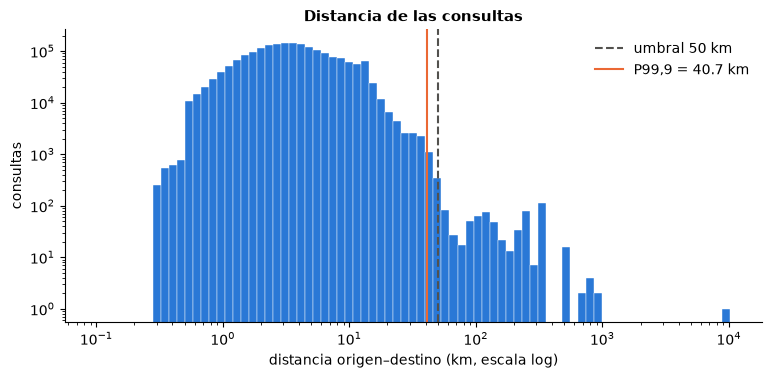

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(d_km, bins=np.logspace(-1, np.log10(d_km.max()), 80), color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(config.DIST_MAX_M / 1000, color=TINTA, ls="--", label=f"umbral {config.DIST_MAX_M // 1000} km")
ax.axvline(M["distancia_p99_9_km"], color=NARANJA, label=f"P99,9 = {M['distancia_p99_9_km']} km")
ax.set(xscale="log", yscale="log", xlabel="distancia origen–destino (km, escala log)", ylabel="consultas",
       title="Distancia de las consultas")
ax.legend(frameon=False)
guardar_figura(fig, "distancia", FASE)
tiempo("calidad")

## 4. Usuarios anómalos
**Tipo de datos:** numéricos agregados por usuario.

Se calculan seis señales de uso no humano o de prueba: volumen, intensidad diaria, dispersión de orígenes, ráfaga en
un día, ausencia de rutina y consultas muy rápidas. Un usuario se marca como anómalo solo con al menos
`MIN_SENALES` señales, porque una sola (por ejemplo, consultar rápido) también la tienen usuarios intensivos legítimos.

In [9]:
usuarios = limpieza.senales_usuario(consultas)
senales = pl.DataFrame({"senal": [c for c in usuarios.columns if c.startswith("s_")]}).with_columns(
    pl.col("senal").map_elements(lambda s: int(usuarios[s].sum()), return_dtype=pl.Int64).alias("usuarios"))
anomalos = usuarios.filter(pl.col("anomalo"))
M.update({"usuarios": usuarios.height, "usuarios_anomalos": anomalos.height,
          "consultas_de_anomalos": int(anomalos["n_consultas"].sum()),
          "usuarios_senal_rapido": int(usuarios["s_rapido"].sum())})
print({k: M[k] for k in ("usuarios", "usuarios_anomalos", "consultas_de_anomalos", "usuarios_senal_rapido")})
guardar_tabla(senales, "usuarios_senales", FASE)
tiempo("usuarios")

{'usuarios': 130545, 'usuarios_anomalos': 2, 'consultas_de_anomalos': 233, 'usuarios_senal_rapido': 10511}
⏱ usuarios: 12.6 s (acumulado 29 s)


## 5. Cobertura temporal
**Tipo de datos:** temporales (semanas ISO, horas y días de la semana).

Se cuenta cuántas semanas tienen datos, cuáles faltan (el hueco) y cuáles están incompletas. Se usan filas sin copias
exactas, porque dos exportaciones repiten la última semana de 2022. El hueco **no se imputa**: se documenta y el
preprocesamiento registra las semanas efectivamente observadas.

In [10]:
unicas = consultas.filter(pl.struct(datos_cols).is_first_distinct())
semanal = guardar_tabla(limpieza.cobertura_semanal(unicas), "cobertura_semanal", FASE)
inicio_hueco, fin_hueco = limpieza.limites_hueco(semanal)
completas = semanal.filter(pl.col("completa"))
M.update({"semanas_periodo": semanal.height, "semanas_observadas": int(semanal["observada"].sum()),
          "semanas_faltantes": int((~semanal["observada"]).sum()), "semanas_completas": completas.height,
          "hueco_inicio": str(inicio_hueco), "hueco_fin": str(fin_hueco),
          "media_semanal_antes_hueco": round(completas.filter(pl.col("inicio") < inicio_hueco)["consultas"].mean()),
          "media_semanal_despues_hueco": round(completas.filter(pl.col("inicio") >= fin_hueco)["consultas"].mean())})
print({k: M[k] for k in M if k.startswith(("semanas", "hueco", "media_semanal"))})

{'semanas_periodo': 91, 'semanas_observadas': 84, 'semanas_faltantes': 7, 'semanas_completas': 78, 'hueco_inicio': '2024-03-11', 'hueco_fin': '2024-04-29', 'media_semanal_antes_hueco': 22731, 'media_semanal_despues_hueco': 39864}


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/cobertura_semanal.png')

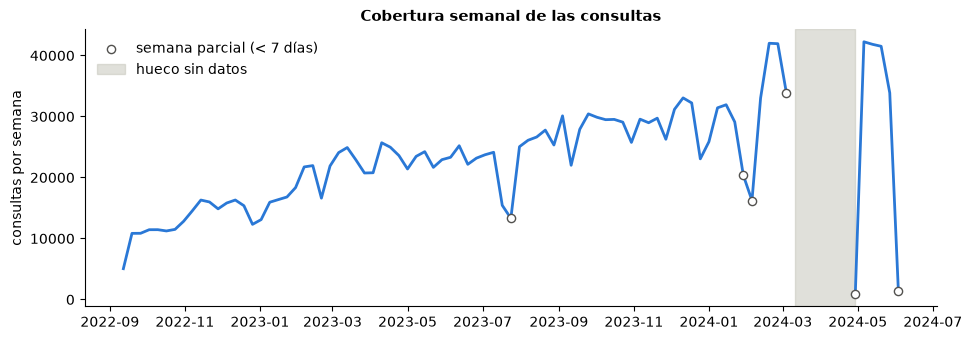

In [11]:
serie = semanal.with_columns(pl.when(pl.col("observada")).then(pl.col("consultas")).alias("y"))  # hueco vacío, no 0
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(serie["inicio"], serie["y"].cast(pl.Float64).fill_null(np.nan), color=AZUL, lw=2)
parciales = semanal.filter(pl.col("observada") & ~pl.col("completa"))
ax.scatter(parciales["inicio"], parciales["consultas"], s=35, facecolor="white", edgecolor=TINTA, zorder=3,
           label="semana parcial (< 7 días)")
ax.axvspan(inicio_hueco, fin_hueco, color=GRIS, alpha=0.5, label="hueco sin datos")
ax.set(ylabel="consultas por semana", title="Cobertura semanal de las consultas")
ax.legend(frameon=False)
guardar_figura(fig, "cobertura_semanal", FASE)

El perfil por hora y día de la semana describe **cuándo** se consulta. No entra al modelo (el estimando es
transversal), pero muestra que la señal corresponde a movilidad cotidiana.

⏱ tiempo: 3.5 s (acumulado 32 s)


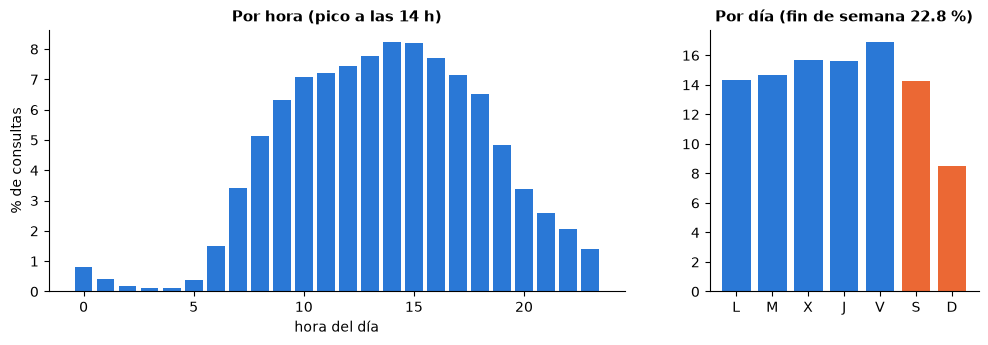

In [12]:
perfil = guardar_tabla(eda.perfil_temporal(unicas), "perfil_temporal", FASE)
hora, dia = perfil.filter(pl.col("dimension") == "hora"), perfil.filter(pl.col("dimension") == "dia_semana")
M.update({"hora_pico": int(hora.sort("pct", descending=True)["valor"][0]),
          "pct_fin_de_semana": round(float(dia.filter(pl.col("valor") >= 6)["pct"].sum()), 1)})
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [3, 1.4]})
a1.bar(hora["valor"], hora["pct"], color=AZUL)
a1.set(xlabel="hora del día", ylabel="% de consultas", title=f"Por hora (pico a las {M['hora_pico']} h)")
a2.bar(["L", "M", "X", "J", "V", "S", "D"], dia["pct"], color=[AZUL] * 5 + [NARANJA] * 2)
a2.set(title=f"Por día (fin de semana {M['pct_fin_de_semana']} %)")
guardar_figura(fig, "perfil_temporal", FASE)
tiempo("tiempo")

## 6. Distribución espacial y área de estudio
**Tipo de datos:** espaciales (coordenadas y celdas H3).

¿Qué región contiene los orígenes? Se toman los orígenes con coordenadas correctas de usuarios no anómalos, **sin
condición de distancia**, y se comparan envolventes: de todas las celdas ocupadas o de su componente H3 contigua
principal (k = 1, 2, 3). Sin componente, unos pocos orígenes en otras ciudades estiran la región a casi todo el país.

In [13]:
es_anomalo = pl.col("userID").is_in(anomalos["userID"].implode())
origenes = espacial.agregar_celda(consultas.filter(limpieza.origen_valido() & ~es_anomalo).select("lat_orig", "lon_orig"),
                                  "lat_orig", "lon_orig", "h3_origin")
ocupadas = set(origenes["h3_origin"].to_list())
filas, geoms = [], {}
for k in [None, 1, 2, 3]:
    comp = ocupadas if k is None else espacial.componente_principal(ocupadas, k)
    pts = origenes.filter(pl.col("h3_origin").is_in(sorted(comp))).unique(["lat_orig", "lon_orig"])
    geoms[k] = espacial.envolvente(pts["lat_orig"].to_numpy(), pts["lon_orig"].to_numpy(), config.BUFFER_AREA_M)
    filas.append({"variante": "todas las celdas" if k is None else f"componente k={k}", "celdas": len(comp),
                  "area_km2": round(espacial.area_km2(geoms[k]), 1)})
guardar_tabla(pl.DataFrame(filas), "area_variantes", FASE)

variante,celdas,area_km2
str,i64,f64
"""todas las celdas""",1516,485940.1
"""componente k=1""",919,1505.7
"""componente k=2""",1076,1965.4
"""componente k=3""",1195,3040.9


Se adopta la componente con `K_COMPONENTE` = 1 más un margen de `BUFFER_AREA_M`: depende solo de dónde están los
orígenes y deja fuera los orígenes aislados. El centroide de esa región se compara con la Plaza 14 de Septiembre,
candidata a centro de referencia exógeno.

In [14]:
AREA = geoms[config.K_COMPONENTE]
CENTROIDE = espacial.centroide_area(AREA)
PLAZA = config.CENTRO_REFERENCIA
lat_o, lon_o = origenes["lat_orig"].to_numpy(), origenes["lon_orig"].to_numpy()
en_area = espacial.dentro(AREA, lat_o, lon_o)
M.update({"area_km2": round(espacial.area_km2(AREA), 1), "pct_origenes_en_area": round(float(en_area.mean() * 100), 2),
          "area_todas_celdas_km2": filas[0]["area_km2"],
          "centroide_a_plaza_km": round(float(espacial.haversine_km(np.array([CENTROIDE[0]]), np.array([CENTROIDE[1]]),
                                                                    PLAZA["lat"], PLAZA["lon"])[0]), 2)})
print({k: M[k] for k in ("area_km2", "pct_origenes_en_area", "area_todas_celdas_km2", "centroide_a_plaza_km")})

{'area_km2': 1505.7, 'pct_origenes_en_area': 99.87, 'area_todas_celdas_km2': 485940.1, 'centroide_a_plaza_km': 7.82}


⏱ espacio: 11.8 s (acumulado 44 s)


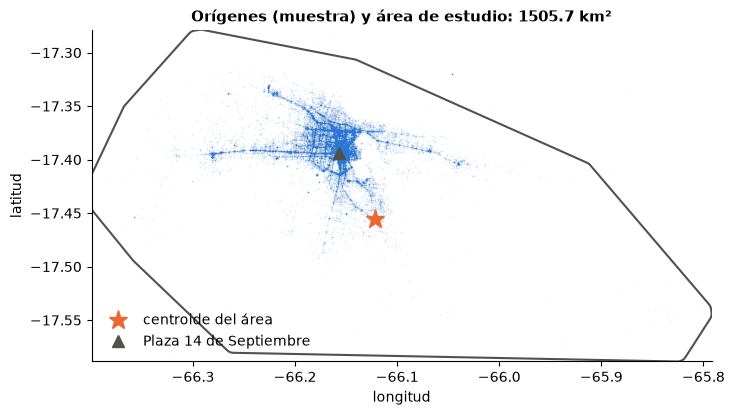

In [15]:
muestra = np.random.default_rng(config.SEMILLA).choice(lat_o.size, 60_000, replace=False)
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(lon_o[muestra], lat_o[muestra], s=1, color=AZUL, alpha=0.08, lw=0)
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1.5)
ax.plot(CENTROIDE[1], CENTROIDE[0], "*", color=NARANJA, ms=14, label="centroide del área")
ax.plot(PLAZA["lon"], PLAZA["lat"], "^", color=TINTA, ms=8, label="Plaza 14 de Septiembre")
minx, miny, maxx, maxy = AREA.bounds
ax.set(xlim=(minx, maxx), ylim=(miny, maxy), xlabel="longitud", ylabel="latitud",
       title=f"Orígenes (muestra) y área de estudio: {M['area_km2']} km²")
ax.legend(frameon=False, loc="lower left")
guardar_figura(fig, "area_estudio", FASE)
tiempo("espacio")

## 7. Red de transporte mapeada (GTFS)
**Tipo de datos:** de red (líneas, trazados, paradas y frecuencias).

Qué red describe el feed, desde cuándo declara vigencia (frente al período de las consultas) y qué parte de la
demanda se origina cerca de algún trazado.

In [16]:
res_gtfs = guardar_tabla(eda.resumen_gtfs(gtfs), "gtfs_resumen", FASE)
g = dict(res_gtfs.iter_rows())
d_trazado = espacial.distancia_trazado_m(lat_o[en_area], lon_o[en_area])
M.update({"gtfs_agencias": int(g["filas_agency"]), "gtfs_lineas": int(g["filas_routes"]),
          "gtfs_recorridos": int(g["filas_trips"]), "gtfs_paradas": int(g["filas_stops"]),
          "gtfs_trazado_mediana_km": g["trazado_mediana_km"], "gtfs_frecuencia_mediana_min": g["frecuencia_mediana_min"],
          "pct_origenes_cerca_trazado": round(float((d_trazado <= config.COBERTURA_M).mean() * 100), 2)})
print({k: M[k] for k in M if k.startswith(("gtfs", "pct_origenes_cerca"))})

{'gtfs_tablas': 11, 'gtfs_vigencia_inicio': '20240101', 'gtfs_agencias': 43, 'gtfs_lineas': 141, 'gtfs_recorridos': 626, 'gtfs_paradas': 22320, 'gtfs_trazado_mediana_km': 20.22, 'gtfs_frecuencia_mediana_min': 5.0, 'pct_origenes_cerca_trazado': 99.47}


⏱ gtfs: 19.0 s (acumulado 63 s)


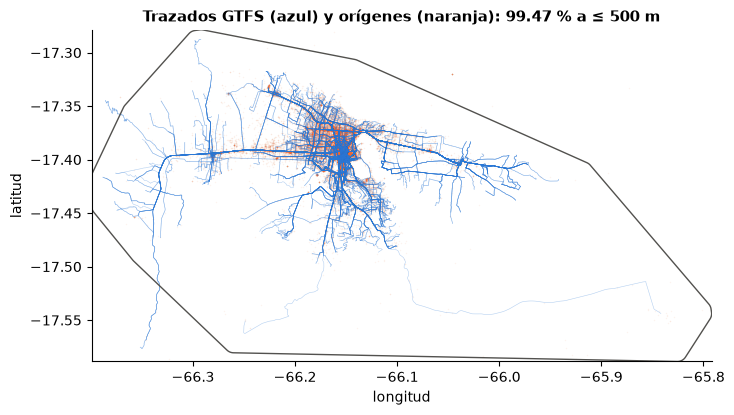

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.add_collection(LineCollection(espacial.lineas_trazado(gtfs["shapes"]), colors=AZUL, linewidths=0.4, alpha=0.35))
ax.scatter(lon_o[muestra], lat_o[muestra], s=1, color=NARANJA, alpha=0.08, lw=0)
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1)
ax.set(xlim=(minx, maxx), ylim=(miny, maxy), xlabel="longitud", ylabel="latitud",
       title=f"Trazados GTFS (azul) y orígenes (naranja): {M['pct_origenes_cerca_trazado']} % a ≤ {config.COBERTURA_M} m")
guardar_figura(fig, "gtfs_red_y_demanda", FASE)
tiempo("gtfs")

## 8. Población residente (Kontur 2023)
**Tipo de datos:** espaciales y numéricos (habitantes por celda H3).

Cuánta población hay en el área y cuántas zonas pobladas no registran ningún origen: esas zonas deben entrar al
análisis con cero consultas, porque el cero es precisamente la señal que se busca interpretar.

In [18]:
k_lat, k_lon = espacial.centroides(kontur["h3_cell"].to_list())
k_area = kontur.filter(pl.Series(espacial.dentro(AREA, k_lat, k_lon)))
M.update({"kontur_celdas_area": k_area.height, "poblacion_area": int(k_area["population"].sum()),
          "kontur_celdas_sin_origenes": k_area.filter(~pl.col("h3_cell").is_in(sorted(ocupadas))).height,
          "kontur_celdas_menos_pop_min": int((k_area["population"] < config.POP_MIN).sum())})
print({k: M[k] for k in M if k.startswith(("kontur_celdas", "poblacion"))})
tiempo("kontur")

{'kontur_celdas_bolivia': 145929, 'kontur_celdas_area': 1577, 'poblacion_area': 1223871, 'kontur_celdas_sin_origenes': 609, 'kontur_celdas_menos_pop_min': 202}
⏱ kontur: 0.9 s (acumulado 64 s)


## 9. Variable objetivo candidata: consultas por zona
**Tipo de datos:** numéricos (conteos por zona).

Se aplican en memoria los filtros candidatos, en orden, para medir cuánto quita cada uno; luego se cuenta
`query_count` por zona y se suman con 0 las zonas pobladas sin consultas. El preprocesamiento repetirá exactamente
estos pasos y los guardará.

In [19]:
limpias, flujo = limpieza.filtrar_consultas(consultas, AREA, anomalos["userID"])
zonas = features.tabla_por_zona(limpias, kontur, AREA)
M.update({"consultas_validas": limpias.height, "pct_consultas_validas": round(limpias.height / consultas.height * 100, 2),
          "zonas_area": zonas.height, "zonas_con_consultas": int((zonas["query_count"] > 0).sum())})
guardar_tabla(flujo, "flujo_candidato", FASE)

paso,regla,filas_eliminadas,filas_despues,pct_conservado
i64,str,i64,i64,f64
0,"""consultas crudas""",0,1927675,100.0
1,"""origen (0,0)""",3,1927672,100.0
2,"""origen fuera de Bolivia""",9,1927663,99.999
3,"""copia de duplicado exacto""",60,1927603,99.996
4,"""origen fuera del área de estud…",2509,1925094,99.866
5,"""distancia > 50 km""",283,1924811,99.851
6,"""usuario anómalo""",233,1924578,99.839


La tasa por habitante solo es estable con población suficiente, así que la distribución se describe sobre las zonas
con al menos `POP_MIN` habitantes. Se mide la proporción de ceros, la concentración (Gini, peso de las 10 primeras
zonas) y la sobredispersión (varianza frente a la media).

In [20]:
modelo = zonas.filter(pl.col("population") >= config.POP_MIN).with_columns(
    (pl.col("query_count") / pl.col("population") * 1000).alias("tasa_1000"))
q = modelo["query_count"].to_numpy()
M.update({"zonas_pop_min": modelo.height, "pct_ceros_pop_min": round(float((q == 0).mean() * 100), 2),
          "gini_query_count": round(espacial.gini(q), 3),
          "pct_top10_zonas": round(float(np.sort(q)[-10:].sum() / q.sum() * 100), 1),
          "varianza_sobre_media": round(float(q.var() / q.mean()))})
claves = ["zonas_pop_min", "pct_ceros_pop_min", "gini_query_count", "pct_top10_zonas", "varianza_sobre_media"]
guardar_tabla(pl.DataFrame({"medida": claves, "valor": [float(M[k]) for k in claves]}), "objetivo_resumen", FASE)

medida,valor
str,f64
"""zonas_pop_min""",1381.0
"""pct_ceros_pop_min""",32.15
"""gini_query_count""",0.948
"""pct_top10_zonas""",42.0
"""varianza_sobre_media""",46569.0


⏱ objetivo: 10.0 s (acumulado 74 s)


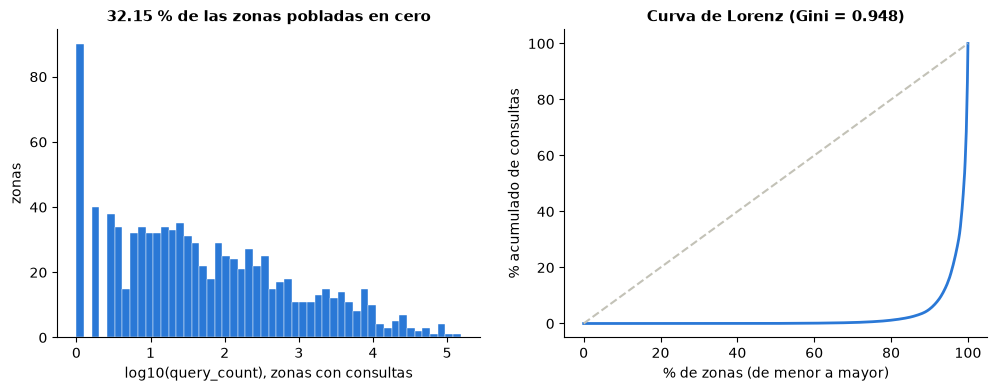

In [21]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(np.log10(q[q > 0]), bins=50, color=AZUL, edgecolor="white", linewidth=0.3)
a1.set(xlabel="log10(query_count), zonas con consultas", ylabel="zonas",
       title=f"{M['pct_ceros_pop_min']} % de las zonas pobladas en cero")
lx, ly = espacial.lorenz(q)
a2.plot(lx * 100, ly * 100, color=AZUL, lw=2)
a2.plot([0, 100], [0, 100], color=GRIS, ls="--")
a2.set(xlabel="% de zonas (de menor a mayor)", ylabel="% acumulado de consultas",
       title=f"Curva de Lorenz (Gini = {M['gini_query_count']})")
guardar_figura(fig, "objetivo_distribucion", FASE)
tiempo("objetivo")

## 10. Relaciones con la población y el territorio
**Tipo de datos:** numéricos (asociación de Spearman, sin causalidad).

Se calculan las variables territoriales candidatas (población de las coronas H3, distancia a la Plaza y al
centroide del área, distancia al trazado GTFS) y su asociación con el conteo y con la tasa por 1.000 habitantes.

In [22]:
ctx = features.agregar_territoriales(modelo, kontur)
ctx = features.agregar_contraste_gtfs(ctx).with_columns(pl.Series(
    "dist_centroide_km", espacial.haversine_km(ctx["lat"].to_numpy(), ctx["lon"].to_numpy(), *CENTROIDE)))
variables = ["population", "pop_ring1", "pop_ring2", "dist_centro_km", "dist_centroide_km", "dist_trazado_m"]
rel = pl.DataFrame([{"variable": v, "objetivo": o, "spearman": round(float(spearmanr(ctx[v], ctx[o]).statistic), 3)}
                    for v in variables for o in ("query_count", "tasa_1000")])
M.update({f"spearman_{r['objetivo']}_{r['variable']}": r["spearman"] for r in rel.iter_rows(named=True)})
guardar_tabla(rel, "relaciones", FASE).filter(pl.col("objetivo") == "query_count")

variable,objetivo,spearman
str,str,f64
"""population""","""query_count""",0.855
"""pop_ring1""","""query_count""",0.836
"""pop_ring2""","""query_count""",0.804
"""dist_centro_km""","""query_count""",-0.697
"""dist_centroide_km""","""query_count""",-0.476
"""dist_trazado_m""","""query_count""",-0.763


La distancia a la Plaza (centro exógeno) se asocia más con las consultas que la distancia al centroide del área, así
que se propone la Plaza como centro de referencia. El gráfico muestra la relación con la población y separa las zonas
cercanas y lejanas al trazado mapeado.

⏱ relaciones: 2.8 s (acumulado 77 s)


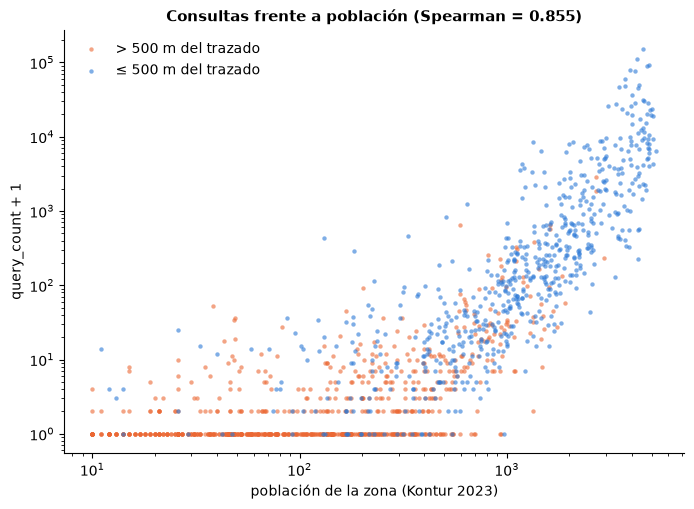

In [23]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for cub, color, etiqueta in [(0, NARANJA, f"> {config.COBERTURA_M} m del trazado"),
                             (1, AZUL, f"≤ {config.COBERTURA_M} m del trazado")]:
    s = ctx.filter(pl.col("gtfs_covered") == cub)
    ax.scatter(s["population"], s["query_count"] + 1, s=10, color=color, alpha=0.6, lw=0, label=etiqueta)
ax.set(xscale="log", yscale="log", xlabel="población de la zona (Kontur 2023)", ylabel="query_count + 1",
       title=f"Consultas frente a población (Spearman = {M['spearman_query_count_population']})")
ax.legend(frameon=False)
guardar_figura(fig, "objetivo_vs_poblacion", FASE)
M["zonas_cubiertas_pop_min"] = int(ctx["gtfs_covered"].sum())
tiempo("relaciones")

## 11. Autocorrelación espacial
**Tipo de datos:** espaciales (vecindad H3 y clusters locales).

¿Se parecen las zonas vecinas? El I de Moran se calcula por anillo H3 (correlograma) para ver hasta qué distancia
persiste la dependencia; LISA ubica los clusters. Se usa `log(1 + tasa)` para que unas pocas zonas extremas no
dominen. Si la dependencia persiste a varios km, una validación aleatoria sobrestimaría el desempeño.

In [24]:
celdas = ctx["h3_cell"].to_list()
y_tasa = np.log1p(ctx["tasa_1000"].to_numpy())
corr = espacial.correlograma_moran(y_tasa, celdas, config.K_MAX_CORRELOGRAMA, config.PERMUTACIONES, config.SEMILLA)
M.update({"moran_I_k1": corr["moran_I"][0], "moran_p_k1": corr["p_valor"][0], "moran_I_k_max": corr["moran_I"][-1]})
guardar_tabla(corr, "autocorrelacion", FASE)

orden_k,distancia_aprox_km,moran_I,p_valor
i64,f64,f64,f64
1,0.92,0.7161,0.002
2,1.84,0.6399,0.002
3,2.76,0.5773,0.002
4,3.68,0.5094,0.002
5,4.6,0.4603,0.002


⏱ autocorrelacion: 2.6 s (acumulado 80 s)


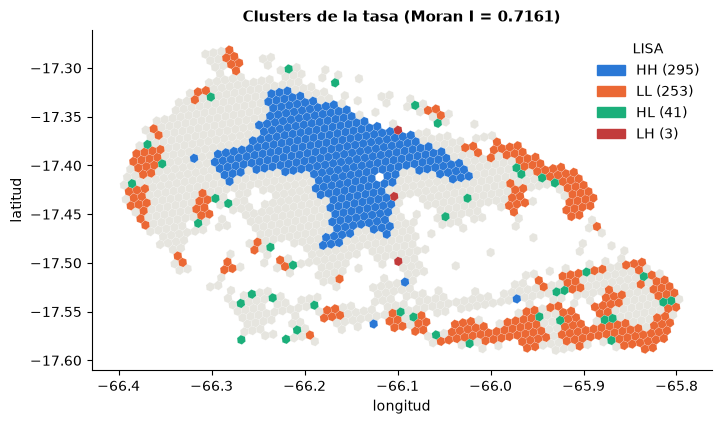

In [25]:
ctx = ctx.with_columns(pl.Series("lisa", espacial.lisa(y_tasa, celdas, config.PERMUTACIONES, config.SEMILLA)))
M.update({f"lisa_{k}": int((ctx["lisa"] == k).sum()) for k in ("HH", "LL", "HL", "LH")})
geo = espacial.geo_zonas(ctx.select("h3_cell", "lisa"))
fig, ax = plt.subplots(figsize=(8, 7))
for tipo, color in [("no significativo", "#e6e5df"), ("sin vecinas", "#e6e5df"), ("HH", AZUL), ("LL", NARANJA),
                    ("HL", VERDE), ("LH", ROJO)]:
    geo[geo["lisa"] == tipo].plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in (AZUL, NARANJA, VERDE, ROJO)],
          labels=[f"{t} ({M['lisa_' + t]})" for t in ("HH", "LL", "HL", "LH")], frameon=False, title="LISA")
ax.set(xlabel="longitud", ylabel="latitud", title=f"Clusters de la tasa (Moran I = {M['moran_I_k1']})")
guardar_figura(fig, "lisa", FASE)
tiempo("autocorrelacion")

## 12. Verificaciones

### 12.1 El flujo de filtros cuadra
Lo eliminado en cada paso más lo que queda debe sumar exactamente las consultas crudas.

In [26]:
assert flujo["filas_eliminadas"].sum() + limpias.height == consultas.height, "El flujo no cuadra"
print(f"{consultas.height:,} crudas = {flujo['filas_eliminadas'].sum():,} eliminadas + {limpias.height:,} válidas")

1,927,675 crudas = 3,097 eliminadas + 1,924,578 válidas


### 12.2 El objetivo suma las consultas válidas
Cada consulta válida cae en exactamente una zona, y ninguna zona se repite.

In [27]:
assert zonas["query_count"].sum() == limpias.height, "query_count no suma las consultas válidas"
assert zonas["h3_cell"].is_unique().all(), "Hay zonas repetidas"
print(f"{zonas.height:,} zonas suman {zonas['query_count'].sum():,} consultas")

1,628 zonas suman 1,924,578 consultas


### 12.3 No quedan usuarios anómalos ni orígenes fuera del área
Las consultas válidas no contienen usuarios marcados y todos sus orígenes están dentro del área.

In [28]:
assert not limpias["userID"].is_in(anomalos["userID"].implode()).any(), "Quedan usuarios anómalos"
assert espacial.dentro(AREA, limpias["lat_orig"].to_numpy(), limpias["lon_orig"].to_numpy()).all()
print("Sin usuarios anómalos; todos los orígenes dentro del área")

Sin usuarios anómalos; todos los orígenes dentro del área


## 13. Cierre

Criterios que fija este EDA para el preprocesamiento (cada uno respaldado por una métrica de esta fase):

| Criterio | Evidencia en `metricas.json` |
|---|---|
| Área = envolvente de la componente H3 contigua (k=1) de los orígenes válidos + 1 km | `area_km2`, `area_todas_celdas_km2`, `pct_origenes_en_area` |
| Filtro de distancia ≤ 50 km: decide qué consultas cuentan, no dibuja el área | `distancia_p99_9_km`, `pct_distancia_mayor_max` |
| Usuario anómalo con ≥ 2 de 6 señales | `usuarios_anomalos`, `usuarios_senal_rapido` |
| Solo se eliminan las copias exactas | `duplicados_exactos` |
| Zonas pobladas sin consultas entran con 0; no se imputa | `kontur_celdas_sin_origenes`, `pct_ceros_pop_min` |
| El hueco temporal se documenta y no se imputa | `semanas_faltantes`, `hueco_inicio`, `hueco_fin` |
| Centro de referencia = Plaza 14 de Septiembre | `spearman_query_count_dist_centro_km` frente a `..._dist_centroide_km` |
| Validación por bloques espaciales | `moran_I_k1`, `moran_I_k_max` |
| Modelos de conteo con offset de población y sobredispersión | `varianza_sobre_media`, `gini_query_count` |

In [29]:
M.update({"semilla": config.SEMILLA, "dist_max_m": config.DIST_MAX_M, "pop_min": config.POP_MIN,
          "cobertura_m": config.COBERTURA_M, "min_senales": config.MIN_SENALES})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 1.1 s (acumulado 81 s)
84 métricas → resultados/01_eda/metricas.json
